# Experimento TFM: One-Class SVM vs Isolation Forest

Este notebook implementa la aplicación experimental para comparar **One-Class SVM** e **Isolation Forest** en el dataset de fraude con tarjeta.

Puntos clave:
- La etiqueta `fraud` **no se usa para entrenar**.
- La etiqueta se usa únicamente para evaluar con ROC-AUC, PR-AUC, matriz de confusión, precision, recall y F1.
- Se incluye una opción para añadir variables irrelevantes artificiales y estudiar sensibilidad a la dimensión.


In [2]:
# ============================================
# 1. Librerías y configuración
# ============================================

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42 # fijamos la semilla para que los resultados sean interpretables
np.random.seed(RANDOM_STATE)


In [3]:
# ============================================
# 2. Cargar datos
# ============================================

df = pd.read_csv("card_transdata.csv")

print("Dimensión del dataset:", df.shape)
display(df.head())

print("\nTipos de variables:")
print(df.dtypes)

print("\nValores perdidos:")
print(df.isna().sum())

print("\nDistribución de la etiqueta fraud:")
print(df["fraud"].value_counts())
print(df["fraud"].value_counts(normalize=True))


Dimensión del dataset: (1000000, 8)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0



Tipos de variables:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Valores perdidos:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Distribución de la etiqueta fraud:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64
fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64


1. El dataset contiene 1.000.000 de transacciones y 8 variables,
   lo que permite estudiar el comportamiento de los algoritmos
   en un problema de gran tamaño.

2. Todas las variables son numéricas y no hay valores perdidos,
   por lo que no se necesita aplicar técnicas de imputación.

3. El problema presenta un fuerte desbalanceo:
      - 91.26% transacciones normales
      - 8.74% transacciones fraudulentas

4. Este desbalanceo es característico de problemas de detección
   de anomalías y justifica el uso de métricas como:
      - ROC-AUC
      - PR-AUC
      - Precision
      - Recall
      - F1-score

5. La etiqueta 'fraud' NO se usará durante el entrenamiento.
   Se empleará solo para evaluar el rendimiento de los modelos.

6. El dataset resulta adecuado para comparar One-Class SVM e
   Isolation Forest tanto desde el punto de vista predictivo
   como computacional.

In [4]:
# ============================================
# 3. Separar variables predictoras y etiqueta
# ============================================

target_col = "fraud"

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

feature_cols = X.columns.tolist()

continuous_cols = [
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price"
]

binary_cols = [
    "repeat_retailer",
    "used_chip",
    "used_pin_number",
    "online_order"
]

print("Variables continuas:", continuous_cols)
print("Variables binarias:", binary_cols)


Variables continuas: ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
Variables binarias: ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']


In [5]:
# ============================================
# 4. División train-test
# ============================================
# La estratificación se usa solo para conservar aproximadamente
# la proporción de fraude en train y test.
# La etiqueta NO se usa para ajustar los modelos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("\nProporción de fraude en train:")
print(y_train.value_counts(normalize=True))
print("\nProporción de fraude en test:")
print(y_test.value_counts(normalize=True))


Train: (700000, 7)
Test: (300000, 7)

Proporción de fraude en train:
fraud
0    0.912597
1    0.087403
Name: proportion, dtype: float64

Proporción de fraude en test:
fraud
0    0.912597
1    0.087403
Name: proportion, dtype: float64


- El conjunto de datos se ha dividido en:
  - **700.000 observaciones** para entrenamiento.
  - **300.000 observaciones** para test.

- La división mantiene exactamente la misma proporción de fraude en los dos subconjuntos:
  - **91.26 %** de transacciones normales.
  - **8.74 %** de transacciones fraudulentas.

- Esto indica que la partición estratificada se ha realizado correctamente, evitando garndes diferencias en la distribución de clases entre entrenamiento y test.

- Mantener una distribución similar es muy importante en problemas desbalanceados como la detección de fraude, ya que permite obtener una evaluación más representativa del comportamiento de los modelos.

- Las etiquetas solo se usan para conservar la proporción de fraude y para evaluar más adelante el rendimiento de los algoritmos. No se usan durante el entrenamiento de los modelos.

In [6]:
# ============================================
# 5. Añadir variables irrelevantes artificiales
# ============================================

def add_irrelevant_features(
    X_train,
    X_test,
    n_gaussian=0,
    n_uniform=0,
    n_binary=0,
    n_redundant=0,
    random_state=42
):
    """
    Añade variables irrelevantes sin usar la etiqueta.

    - Gaussianas: ruido N(0,1).
    - Uniformes: ruido U(0,1).
    - Binarias: Bernoulli(0.5).
    - Redundantes: copias ruidosas de variables continuas originales.
    """
    rng = np.random.default_rng(random_state)
    Xtr = X_train.copy()
    Xte = X_test.copy()

    n_tr = len(Xtr)
    n_te = len(Xte)

    for i in range(n_gaussian):
        Xtr[f"noise_gaussian_{i+1}"] = rng.normal(0, 1, n_tr)
        Xte[f"noise_gaussian_{i+1}"] = rng.normal(0, 1, n_te)

    for i in range(n_uniform):
        Xtr[f"noise_uniform_{i+1}"] = rng.uniform(0, 1, n_tr)
        Xte[f"noise_uniform_{i+1}"] = rng.uniform(0, 1, n_te)

    for i in range(n_binary):
        Xtr[f"noise_binary_{i+1}"] = rng.integers(0, 2, n_tr)
        Xte[f"noise_binary_{i+1}"] = rng.integers(0, 2, n_te)

    base_cols = [
        "distance_from_home",
        "distance_from_last_transaction",
        "ratio_to_median_purchase_price"
    ]

    for i in range(n_redundant):
        col = base_cols[i % len(base_cols)]
        scale = Xtr[col].std()
        Xtr[f"redundant_{col}_{i+1}"] = Xtr[col] + rng.normal(0, 0.01 * scale, n_tr)
        Xte[f"redundant_{col}_{i+1}"] = Xte[col] + rng.normal(0, 0.01 * scale, n_te)

    return Xtr, Xte


# Escenarios:
# 1) Dataset original
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# 2) Dataset con variables irrelevantes
X_train_noise, X_test_noise = add_irrelevant_features(
    X_train,
    X_test,
    n_gaussian=10,
    n_uniform=5,
    n_binary=5,
    n_redundant=3,
    random_state=RANDOM_STATE
)

print("Original:", X_train_original.shape)
print("Con ruido:", X_train_noise.shape)


Original: (700000, 7)
Con ruido: (700000, 30)


- Se han considerado dos escenarios experimentales:
  - Dataset original con **7 variables**.
  - Dataset ampliado con **30 variables** añadiendo variables irrelevantes artificiales.

- Las variables añadidas son ruido gaussiano, variables uniformes, variables binarias aleatorias y variables redundantes.

- El objetivo de esta ampliación es estudiar el comportamiento de One-Class SVM e Isolation Forest en espacios de mayor dimensión y analizar su sensibilidad frente a variables no informativas.

- Este experimento permitirá evaluar si aumentar artificialmente la dimensión afecta de manera distinta a ambos métodos, sobre todo en términos de:
  - capacidad de detección,
  - estabilidad,
  - robustez,
  - y coste computacional.

- Este estudio resulta especialmente interesante en el caso de OCSVM,  ya que depende de medidas de similitud y kernels basados en distancias.

In [7]:
# ============================================
# 6. Preprocesamiento
# ============================================

def make_preprocessor(X_train):
    """
    Escala variables continuas mediante RobustScaler.
    Las variables binarias se dejan sin escalar.
    Las variables artificiales continuas también se escalan.
    """
    binary_like = []
    continuous_like = []

    for col in X_train.columns:
        unique_vals = set(pd.Series(X_train[col].dropna().unique()).astype(float))
        if unique_vals.issubset({0.0, 1.0}):
            binary_like.append(col)
        else:
            continuous_like.append(col)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", RobustScaler(), continuous_like),
            ("bin", "passthrough", binary_like)
        ],
        remainder="drop"
    )

    return preprocessor, continuous_like, binary_like


preprocessor_original, cont_original, bin_original = make_preprocessor(X_train_original)

print("Continuas original:", cont_original)
print("Binarias original:", bin_original)


Continuas original: ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
Binarias original: ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']


- Las variables continuas se escalan mediante `RobustScaler`,
  uando estadísticos robustos frente a valores extremos.

- Las variables binarias se mantienen como están, ya que
  sus valores originales (0 y 1) ya son interpretables y comparables.

- El preprocesamiento es esencial sobre todo en One-Class SVM,
  ya que el kernel RBF depende directamente de distancias entre observaciones.

- Isolation Forest es menos sensible a la escala de las variables.

In [8]:
# ============================================
# 7. Funciones auxiliares para entrenamiento y evaluación
# ============================================

def evaluate_scores(y_true, anomaly_score, threshold=None):
    """
    Evalúa scores donde valores mayores significan mayor anomalía.
    Si se proporciona threshold, calcula también métricas binarias.
    """
    results = {
        "roc_auc": roc_auc_score(y_true, anomaly_score),
        "pr_auc": average_precision_score(y_true, anomaly_score)
    }

    if threshold is not None:
        y_pred = (anomaly_score >= threshold).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        results.update({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    return results


def fit_score_isolation_forest(
    X_train,
    X_test,
    n_estimators=200,
    max_samples=256,
    random_state=42
):
    preprocessor, _, _ = make_preprocessor(X_train)

    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            contamination="auto",
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    t0 = time.perf_counter()
    model.fit(X_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    # En sklearn, valores más altos de decision_function indican más normalidad.
    # Por eso cambiamos el signo para que valores mayores indiquen más anomalía.
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)
    score_time = time.perf_counter() - t0

    return model, train_scores, test_scores, fit_time, score_time


def fit_score_ocsvm(
    X_train,
    X_test,
    nu=0.05,
    gamma="scale",
    kernel="rbf",
    max_train_size=50000,
    random_state=42
):
    """
    OCSVM puede ser costoso en datasets grandes.
    Por eso se permite entrenar con una submuestra de entrenamiento.
    La submuestra se elige sin usar etiquetas.
    """
    rng = np.random.default_rng(random_state)

    if len(X_train) > max_train_size:
        idx = rng.choice(len(X_train), size=max_train_size, replace=False)
        X_fit = X_train.iloc[idx].copy()
    else:
        X_fit = X_train.copy()

    preprocessor, _, _ = make_preprocessor(X_fit)

    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", OneClassSVM(
            kernel=kernel,
            nu=nu,
            gamma=gamma
        ))
    ])

    t0 = time.perf_counter()
    model.fit(X_fit)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    # En OCSVM, decision_function > 0 suele indicar inlier.
    # Cambiamos el signo para que valores mayores indiquen más anomalía.
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)
    score_time = time.perf_counter() - t0

    return model, train_scores, test_scores, fit_time, score_time


- Para implementar los algoritmos se usa la librería `scikit-learn` de Python.

- En particular, se emplean las clases:
  - `IsolationForest` para Isolation Forest.
  - `OneClassSVM` para One-Class Support Vector Machine.

- Estas implementaciones proporcionan métodos para:
  - entrenar los modelos (`fit`),
  - calcular anomaly scores (`decision_function`),
  - y realizar predicciones sobre nuevas observaciones.

- En ambos casos se trabaja con los scores continuos generados por los modelos, pudiendo evaluar el rendimiento mediante métricas como ROC-AUC y PR-AUC sin tener que fijar inicialmente un umbral de clasificación.

- Para unificar la interpretación de los resultados, se cambia el signo de `decision_function`, de forma que valores más altos del score indiquen una mayor probabilidad de anomalía.

In [9]:
# ============================================
# 8. Ejecutar experimento
# ============================================

def run_experiment(X_train_exp, X_test_exp, y_test, scenario_name, threshold_quantile=0.95):
    rows = []

    # Isolation Forest
    if_model, if_train_scores, if_test_scores, if_fit_time, if_score_time = fit_score_isolation_forest(
        X_train_exp,
        X_test_exp,
        n_estimators=200,
        max_samples=256,
        random_state=RANDOM_STATE
    )
    if_threshold = np.quantile(if_train_scores, threshold_quantile)
    if_results = evaluate_scores(y_test, if_test_scores, threshold=if_threshold)
    if_results.update({
        "scenario": scenario_name,
        "model": "Isolation Forest",
        "fit_time": if_fit_time,
        "score_time": if_score_time,
        "threshold": if_threshold
    })
    rows.append(if_results)

    # One-Class SVM
    svm_model, svm_train_scores, svm_test_scores, svm_fit_time, svm_score_time = fit_score_ocsvm(
        X_train_exp,
        X_test_exp,
        nu=0.05,
        gamma="scale",
        kernel="rbf",
        max_train_size=50000,
        random_state=RANDOM_STATE
    )
    svm_threshold = np.quantile(svm_train_scores, threshold_quantile)
    svm_results = evaluate_scores(y_test, svm_test_scores, threshold=svm_threshold)
    svm_results.update({
        "scenario": scenario_name,
        "model": "One-Class SVM",
        "fit_time": svm_fit_time,
        "score_time": svm_score_time,
        "threshold": svm_threshold
    })
    rows.append(svm_results)

    return pd.DataFrame(rows), {
        "if_model": if_model,
        "svm_model": svm_model,
        "if_test_scores": if_test_scores,
        "svm_test_scores": svm_test_scores
    }


results_original, models_original = run_experiment(
    X_train_original,
    X_test_original,
    y_test,
    scenario_name="Original",
    threshold_quantile=0.95
)

results_noise, models_noise = run_experiment(
    X_train_noise,
    X_test_noise,
    y_test,
    scenario_name="Con variables irrelevantes",
    threshold_quantile=0.95
)

results = pd.concat([results_original, results_noise], ignore_index=True)
display(results)


,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp,scenario,model,fit_time,score_time,threshold
0,0.743007,0.169562,0.208272,0.118874,0.151358,261930,11849,23104,3117,Original,Isolation Forest,1.917297,17.509688,0.095295
1,0.473980,0.181473,0.383643,0.216468,0.276770,264660,9119,20545,5676,Original,One-Class SVM,21.248719,176.001003,-0.127070
2,0.724748,0.198607,0.271092,0.156363,0.198331,262755,11024,22121,4100,Con variables irrelevantes,Isolation Forest,5.271705,22.344591,0.028604
3,0.502968,0.189789,0.380841,0.217879,0.277182,264491,9288,20508,5713,Con variables irrelevantes,One-Class SVM,32.412148,274.146771,-0.315269


En este bloque se ejecuta el experimento completo para comparar Isolation Forest y One-Class SVM.

Se introduce en la función `run_experiment` un conjunto de entrenamiento, un conjunto de test, las etiquetas reales del test y el nombre del escenario experimental. Se consideran dos escenarios:

- Dataset original.
- Dataset con variables irrelevantes artificiales.

Para cada escenario se entrenan ambos modelos:

1. **Isolation Forest**
   - Se entrena sobre el conjunto de entrenamiento.
   - Se calculan anomaly scores sobre entrenamiento y test.
   - Se fija un umbral usando un percentil de los scores de entrenamiento.
   - Se evalúa el modelo sobre test.

2. **One-Class SVM**
   - Se entrena sobre el conjunto de entrenamiento, usando una submuestra si el tamaño es muy grande.
   - Se calculan anomaly scores sobre entrenamiento y test.
   - Se fija el mismo criterio de umbral basado en percentiles.
   - Se evalúa el modelo sobre test.

El umbral se calcula mediante:

`np.quantile(train_scores, threshold_quantile)`

Por ejemplo, si `threshold_quantile = 0.95`, se consideran anómalas las observaciones cuyo score esté por encima del percentil 95 de los scores de entrenamiento.

Finalmente, se calculan métricas como ROC-AUC, PR-AUC, precision, recall, F1-score y tiempos de ejecución. Los resultados de ambos escenarios se combinan en una única tabla para facilitar la comparación.

## Comparación general entre métodos

- Isolation Forest obtiene mejores valores de **ROC-AUC** en ambos escenarios:
  - Dataset original: **0.743**
  - Dataset con variables irrelevantes: **0.725**

- One-Class SVM devuelve valores de ROC-AUC significativamente inferiores:
  - Dataset original: **0.474**
  - Dataset con variables irrelevantes: **0.503**

- Estos resultados sugieren que IF es capaz de separar mejor observaciones normales y fraudulentas usando los anomaly scores generados por el modelo.

---

## PR-AUC y detección de fraude

- Las diferencias en **PR-AUC** son menores:
  - Isolation Forest:
    - Original: **0.170**
    - Con ruido: **0.199**
  - One-Class SVM:
    - Original: **0.181**
    - Con ruido: **0.190**

- Esto indica que ambos métodos presentan dificultades al identificar el fraude debido al fuerte desbalanceo del problema.

- Sin embargo, Isolation Forest mantiene una mejor capacidad global de discriminación según ROC-AUC.

Aunque los valores de PR-AUC obtenidos no son altos, deben interpretarse teniendo en cuenta el fuerte desbalanceo del problema. En un escenario aleatorio, la métrica PR-AUC sería aproximadamente igual a la proporción de fraude del conjunto de datos ($0.087$), luego los resultados muestran una mejora significativa respecto al comportamiento aleatorio.

---

## Precision y Recall

- One-Class SVM obtiene una mayor precision:
  - Aproximadamente **0.38** en ambos escenarios.

- Isolation Forest presenta una precision menor:
  - Entre **0.21** y **0.27**.

- No obstante, One-Class SVM sigue mostrando valores moderados de recall, lo que indica que detecta solamente una parte de las transacciones fraudulentas.

- Isolation Forest consigue un equilibrio más estable entre recall y capacidad global de discriminación.

---

## Impacto de las variables irrelevantes

- La incorporación de variables irrelevantes aumenta la dimensión del problema de 7 a 30 variables.

- En Isolation Forest:
  - ROC-AUC disminuye ligeramente.
  - PR-AUC mejora ligeramente.
  - El tiempo computacional aumenta moderadamente.

- En One-Class SVM:
  - El tiempo de entrenamiento y evaluación aumenta de forma muy significativa.
  - ROC-AUC continúa siendo bajo incluso tras aumentar la dimensión.

- Estos resultados son coherentes con el análisis teórico realizado previamente:
  - OCSVM es más sensible a la dimensión y al uso de kernels basados en distancias.
  - Isolation Forest muestra una mayor robustez frente a variables irrelevantes.

---

## Coste computacional

- Isolation Forest presenta tiempos de entrenamiento y evaluación considerablemente menores.

- One-Class SVM requiere:
  - más tiempo de entrenamiento,
  - más tiempo de evaluación,
  - y un mayor coste computacional global.

- La diferencia se vuelve aún más notable al aumentar el número de variables.

---

## Conclusión global

- En este problema de detección de fraude, Isolation Forest ofrece un mejor compromiso entre:
  - capacidad predictiva,
  - robustez,
  - estabilidad,
  - y escalabilidad computacional.

- One-Class SVM presenta una mayor sensibilidad a la dimensión y un coste computacional significativamente superior, lo que limita su aplicabilidad en conjuntos de datos grandes.

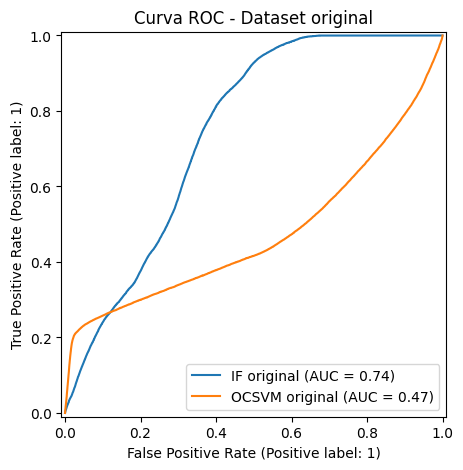

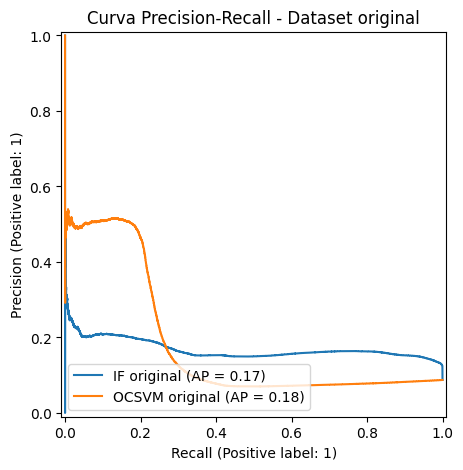

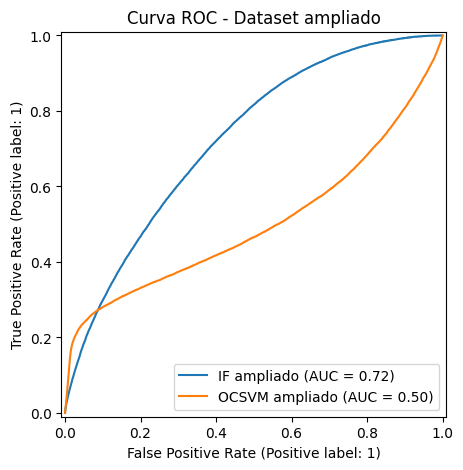

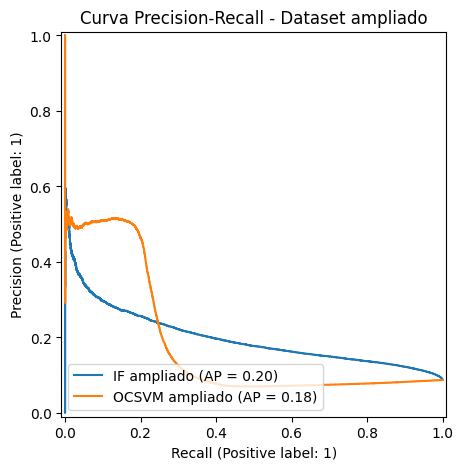

In [11]:
# ============================================
# 9. Curvas ROC y Precision-Recall
# ============================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, models_original["if_test_scores"], name="IF original", ax=ax)
RocCurveDisplay.from_predictions(y_test, models_original["svm_test_scores"], name="OCSVM original", ax=ax)
plt.title("Curva ROC - Dataset original")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, models_original["if_test_scores"], name="IF original", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, models_original["svm_test_scores"], name="OCSVM original", ax=ax)
plt.title("Curva Precision-Recall - Dataset original")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, models_noise["if_test_scores"], name="IF ampliado", ax=ax)
RocCurveDisplay.from_predictions(y_test, models_noise["svm_test_scores"], name="OCSVM ampliado", ax=ax)
plt.title("Curva ROC - Dataset ampliado")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, models_noise["if_test_scores"], name="IF ampliado", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, models_original["svm_test_scores"], name="OCSVM ampliado", ax=ax)
plt.title("Curva Precision-Recall - Dataset ampliado")
plt.show()


## Curvas ROC

- Las curvas ROC muestran una diferencia clara entre ambos métodos.

- Isolation Forest presenta una curva significativamente más alejada de la diagonal aleatoria, alcanzando valores de ROC-AUC cercanos a:
  - **0.74** en el dataset original.
  - **0.72** en el dataset ampliado.

- Esto indica que Isolation Forest consigue separar mejor las transacciones normales y fraudulentas a partir de los anomaly scores generados.

- En cambio, One-Class SVM presenta curvas ROC próximas a la diagonal, especialmente en el dataset original:
  - ROC-AUC ≈ **0.47** en el dataset original.
  - ROC-AUC ≈ **0.50** en el dataset ampliado.

- Esto indica que OCSVM tiene dificultades para establecer una frontera de separación efectiva en este problema.

- La incorporación de variables irrelevantes afecta ligeramente al rendimiento de Isolation Forest, aunque el modelo mantiene una capacidad de discriminación bastante estable.

---

## Curvas Precision-Recall

- Las curvas Precision-Recall muestran la dificultad del problema por el fuerte desbalanceo del conjunto de datos.

- En ambos métodos, la precision disminuye conforme aumenta el recall, lo que indica que detectar un mayor número de fraudes implica aceptar más falsos positivos.

- One-Class SVM alcanza valores altos de precision únicamente para valores muy pequeños de recall. Esto significa que el modelo puede detectar algunas anomalías con bastante confianza, pero le resulta difícil mantener esa precisión al intentar detectar más fraudes.

- Isolation Forest presenta una curva más estable y mantiene valores moderados de precisión para un rango más amplio de recall.

- En el dataset ampliado, IF mejora ligeramente el área bajo la curva Precision-Recall, alcanzando:
  - AP ≈ **0.20** frente a **0.17** en el dataset original.

- Esto sugiere que el método es robusto frente a la incorporación de variables irrelevantes.

---

## Interpretación global

- Las curvas obtenidas son coherentes con el análisis teórico realizado anteriormente:
  - OCSVM es más sensible a la dimensión y a la estructura geométrica de los datos.
  - IF tiene un comportamiento más robusto y estable en presencia de variables irrelevantes.

- En conjunto, IF ofrece un mejor equilibrio entre:
  - capacidad de discriminación,
  - robustez,
  - estabilidad,
  - y escalabilidad computacional.

- Aunque los valores de PR-AUC no son elevados, deben interpretarse teniendo en cuenta que el baseline aleatorio del problema es aproximadamente igual a la proporción de fraude presente en el dataset (~0.087). Por tanto, los resultados obtenidos representan una mejora significativa respecto al azar.

In [12]:
# ============================================
# 10. Guardar resultados
# ============================================

results.to_csv("resultados_ocsvm_if.csv", index=False)
print("Resultados guardados en resultados_ocsvm_if.csv")


Resultados guardados en resultados_ocsvm_if.csv


## Notas metodológicas

- La etiqueta `fraud` no se usa para ajustar los modelos.
- La estratificación en la división train-test se utiliza únicamente para mantener una proporción similar de fraude en ambos subconjuntos.
- El umbral se fija a partir de los scores de entrenamiento mediante un percentil configurable. En el ejemplo se usa el percentil 95, equivalente a marcar aproximadamente un 5% de observaciones como anómalas.
- Para One-Class SVM se usa una submuestra de entrenamiento porque el método puede ser computacionalmente costoso en datasets grandes.
- El signo de `decision_function` se invierte para que, en ambos métodos, valores mayores del score indiquen mayor anomalía.
